### Main paper plot 3.5

Experiments on Science to compare with the ground truth relationships.

Exp 3.5.1: F(S*(Q), Q) vs F(S(Q), Q) for S(Q) from all?/some? methods. In this case, X-axis is K upto 3.

Exp 3.5.2: MAP on ranking obtained by checking if S_1, S_2/S_1, S_3/S_2 and so on are within S^*. Table of MAP values 

In [1]:
import torch
import pickle
import os
import numpy as np
import sys
from tqdm import tqdm

from omegaconf import OmegaConf
from src.utils import partial_chamfer_sim
from src.embedder import ColBERTEmbedder

/mnt/nas/pritish/virtualenvs/muvera_dog/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/mnt/nas/pritish/virtualenvs/muvera_dog/lib/python3.10/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
os.environ['CUDA_VISIBLE_DEVICES'] = '4'

In [3]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import cm

In [4]:
from plot_utils import crop_pdf_with_fitz, crop_pdf_with_pdfcrop, crop_pdf_with_pypdf,\
    legend_labels, method_label_map, methods, legend_color_map, legend_marker_map

In [5]:
methods = methods + ['gold']

In [6]:
%load_ext autoreload
%autoreload 1

%aimport plot_utils

In [7]:
datasets = ['science']
dataset_name = datasets[0]
time_map, max_time_vals = plot_utils.get_time_data(datasets)

science


In [10]:
# Load ground truth data for Science
from src.dataloader import get_dataloader

class DummyConfig:
    loader_type = 'lotte'
    query_type = 'forum'
    dataset_name = dataset_name

dataloader = get_dataloader(DummyConfig())

In [11]:
qrels = dataloader.get_qrels()

In [12]:
corpus, _ = dataloader.get_data()

In [13]:
list(corpus.keys())[:100]

['0',
 '1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 '10',
 '11',
 '12',
 '13',
 '14',
 '15',
 '16',
 '17',
 '18',
 '19',
 '20',
 '21',
 '22',
 '23',
 '24',
 '25',
 '26',
 '27',
 '28',
 '29',
 '30',
 '31',
 '32',
 '33',
 '34',
 '35',
 '36',
 '37',
 '38',
 '39',
 '40',
 '41',
 '42',
 '43',
 '44',
 '45',
 '46',
 '47',
 '48',
 '49',
 '50',
 '51',
 '52',
 '53',
 '54',
 '55',
 '56',
 '57',
 '58',
 '59',
 '60',
 '61',
 '62',
 '63',
 '64',
 '65',
 '66',
 '67',
 '68',
 '69',
 '70',
 '71',
 '72',
 '73',
 '74',
 '75',
 '76',
 '77',
 '78',
 '79',
 '80',
 '81',
 '82',
 '83',
 '84',
 '85',
 '86',
 '87',
 '88',
 '89',
 '90',
 '91',
 '92',
 '93',
 '94',
 '95',
 '96',
 '97',
 '98',
 '99']

In [14]:
corpus, queries = dataloader.get_data()
# corpus: Dict[str, Dict]
keys = list(map(str, corpus.keys()))      # preserve a stable order
id2idx = {k: i for i, k in enumerate(keys)}
idx2id = keys                              # idx -> doc_id

In [15]:
pos_indices = []
missing = []
for qrel_list in qrels.values():                    # qrels: Dict[doc_id -> 1]
    pos_indices_q = []
    missing_q = []

    for k in qrel_list:
        kk = str(k)
        if kk in id2idx:
            pos_indices_q.append(id2idx[kk])
        else:
            missing_q.append(kk)                # log/debug if any don't match

    pos_indices.append(pos_indices_q)
    missing.extend(missing_q)


In [16]:
assert len(missing) == 0, f"Some qrels not found in corpus: {missing}"

In [17]:
assert len(pos_indices) == len(queries)

In [18]:
pos_indices[0]

[1468504,
 1468505,
 1468511,
 1468512,
 1468523,
 1468530,
 1468532,
 1468535,
 1468536,
 1468548,
 1468554,
 1468575,
 1468577,
 1468579,
 1468614,
 1521490,
 1528127,
 1533951,
 1545044,
 1615677,
 1617214,
 1644619]

To generate the scores for the gold sets, we have to use partial_chamfer_sim the same way we do for iid baselines.
That means we have to load the query and corpus embeddings.


In [19]:
len(pos_indices)

2017

In [20]:
# Query indices with >= 2 relevant documents
multi_pos_qids = [i for i, pos in enumerate(pos_indices) if len(pos) >= 2]
len(multi_pos_qids)

1858

In [86]:
def get_S2_scores(scores, q_inds=None):
    "Returns the mean of the first two columns of the scores tensor. If q_inds is provided, only consider those indices."
    col_0 = []
    col_1 = []

    if q_inds is not None:
        for sc in scores[q_inds]:
            col_0.append(sc[0])
            col_1.append(sc[1])
    else:
        for sc in scores:
            col_0.append(sc[0])
            col_1.append(sc[1])
    
    print(f"Number of scores considered: {len(col_0)}")
    # No mean, just take the two columns
    S2_scores = torch.stack([torch.tensor(col_0), torch.tensor(col_1)], dim=1)
    return S2_scores

In [87]:
# Load score data
score_map = {ds: {} for ds in datasets}
score_map_full = {ds: {} for ds in datasets}
ind_map = {ds: {} for ds in datasets}

for ds in datasets:
    for method in methods:
        if method == "gold":
            continue
        inds, scores = plot_utils.get_score_data(ds, method, k=10)
        print(f"Shapes for {ds}, {method}: inds: {inds.shape}, scores: {scores.shape}")
        assert inds.shape == scores.shape, f"Shape mismatch for {ds}, {method}: inds: {inds.shape}, scores: {scores.shape}"
        assert inds.shape[0] > 10
        S2_scores = get_S2(scores, multi_pos_qids)
        score_map[ds][method] = S2_scores.mean(dim=0).numpy()
        score_map_full[ds][method] = S2_scores.numpy()
        ind_map[ds][method] = inds
        print(f"Mean scores for {ds}, {method}: {score_map[ds][method]}")

Method is submodlib lazy, loading from /mnt/nas/pritish/DGX/CMUVERA_IR_ref/pickles/results/greedy_submodlib_LazyGreedy_k10_science_bf_k10_submodlib_no_stop.pkl
Shapes for science, submodlib lazy: inds: torch.Size([2017, 10]), scores: torch.Size([2017, 10])
Number of scores considered: 1858
Mean scores for science, submodlib lazy: [22.083914 24.089863]
Method is submodlib stochastic 0.5, loading from /mnt/nas/pritish/DGX/CMUVERA_IR_ref/pickles/results/greedy_submodlib_StochasticGreedy_k10_science_bf_k10_submodlib_no_stop_eps0.5.pkl
Shapes for science, submodlib stochastic 0.5: inds: torch.Size([2017, 10]), scores: torch.Size([2017, 10])
Number of scores considered: 1858
Mean scores for science, submodlib stochastic 0.5: [19.495888 22.555319]
Method is submodlib ltl 0.1, loading from /mnt/nas/pritish/DGX/CMUVERA_IR_ref/pickles/results/greedy_submodlib_LazierThanLazyGreedy_k10_science_bf_k10_submodlib_no_stop.pkl
File not found: greedy_submodlib_LazierThanLazyGreedy_k10_science_bf_k10_sub

In [21]:
def make_conf():
    # k=15 embedder.mode="disk" augment=False method='baseline' data.loader_type=lotte data.query_type=forum data.dataset_name=writing index=True overwrite_index=True
    sys.argv = ["", f"k=10", f"embedder.mode=disk", f"augment=False", f"method=baseline",
            f"data.loader_type=lotte", f"data.query_type=forum", f"data.dataset_name={dataset_name}",
            "index=False", "overwrite_index=False"]
    print(sys.argv)
    cli_conf = OmegaConf.from_cli()
    main_conf = OmegaConf.load("configs/config.yaml")
    colbert_conf = OmegaConf.load("configs/colbert.yaml")

    conf = OmegaConf.merge(main_conf, colbert_conf, cli_conf)

    return conf

In [30]:
corpus, _ = dataloader.get_data()
len(list(corpus))

1694164

In [22]:
conf = make_conf()

['', 'k=10', 'embedder.mode=disk', 'augment=False', 'method=baseline', 'data.loader_type=lotte', 'data.query_type=forum', 'data.dataset_name=science', 'index=False', 'overwrite_index=False']


In [23]:
embedder = ColBERTEmbedder(conf.embedder)

In [102]:
# Using pos_indices, we have to make a |Q| x max set size matrix of ground truth corpus items.
# Max set size means the largest number of relevant documents for any query.
# For padding purposes, we will repeat the last index in each query's list.

# Later we will index by pos_indices_desired
max_set_size = max(len(p) for p in pos_indices)
gt_indices = np.zeros((len(pos_indices), max_set_size), dtype=np.int32)
for i, p in enumerate(pos_indices):
    for j in range(max_set_size):
        if j < len(p):
            gt_indices[i, j] = p[j]
        else:
            gt_indices[i, j] = p[-1]
gt_indices = torch.from_numpy(gt_indices)

In [103]:
gt_indices.shape

torch.Size([2017, 141])

In [105]:
embedder.embed_full_dataset(dataloader, mode=conf.embedder.mode)
qembs, qmasks = embedder.qembs, embedder.qmasks
gold_chamfer_scores = []

gt_indices = gt_indices.to(embedder.device)
print("Getting the corpus embeddings...")
corpus = embedder.get_corpus(gt_indices)
print("Done getting corpus embeddings.")
print(f"Corpus shape: {corpus.emb.shape}")

with open(f'./gold_set_corpus_{dataset_name}.pkl', 'wb') as f:
    pickle.dump(corpus, f)

/mnt/nas/pritish/DGX/CMUVERA_IR_ref/ColBERT/colbert/utils/amp.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler()
/mnt/nas/pritish/DGX/CMUVERA_IR_ref/ColBERT/colbert/utils/amp.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast() if self.activated else NullContextManager()



#> QueryTokenizer.tensorize(batch_text[0], batch_background[0], bsize) ==
#> Input: Cooling a cup of coffee with help of a spoon, 		 True, 		 None
#> Output IDs: torch.Size([32]), tensor([  101,     1, 11520,  1037,  2452,  1997,  4157,  2007,  2393,  1997,
         1037, 15642,   102,   103,   103,   103,   103,   103,   103,   103,
          103,   103,   103,   103,   103,   103,   103,   103,   103,   103,
          103,   103], device='cuda:0')
#> Output Mask: torch.Size([32]), tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')

./experiments/science/BERT/corpus/compressed_128/batch_0.0.pkl
./experiments/science/BERT/corpus/compressed_128/batch_1.0.pkl
./experiments/science/BERT/corpus/compressed_128/batch_2.0.pkl
./experiments/science/BERT/corpus/compressed_128/batch_3.0.pkl
./experiments/science/BERT/corpus/compressed_128/batch_4.0.pkl
./experiments/science/BERT/corpus/compressed_128/batch_5.0.pkl
./

In [133]:
print("Computing chamfer scores for gold sets...")
gt_S2 = []
gold_chamfer_scores = []

for query_id in tqdm(range(len(queries)), desc="Computing chamfer scores for gold sets"):
    qemb = qembs[query_id:query_id+1]       # (1, Lq, d)
    qmask = qmasks[query_id:query_id+1]     # (1, Lq)
    
    cemb, cmask = corpus[
        (query_id * torch.ones(gt_indices.shape[1], dtype=torch.long)),
        torch.arange(gt_indices.shape[1], dtype=torch.long)
    ]

    out = partial_chamfer_sim(qembs[query_id][qmasks[query_id].bool()], cemb, cmask, device='cuda', bs=1024)
    out_sum = out.sum(dim=0)
    sorted_inds = torch.argsort(out_sum, descending=True)
    sorted_out = out[:, sorted_inds]
    gt_S2.append(gt_indices[query_id][sorted_inds])
    res = torch.cummax(sorted_out, dim=1)[0].sum(dim=0)
    gold_chamfer_scores.append(res)

Computing chamfer scores for gold sets...


Computing chamfer scores for gold sets: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 2017/2017 [00:02<00:00, 803.45it/s]


In [134]:
with open(f"./pickles/results/gold_chamfer_scores_{dataset_name}.pkl", "wb") as f:
    pickle.dump(gold_chamfer_scores, f)

In [135]:
with open(f"./pickles/results/gold_chamfer_scores_{dataset_name}.pkl", "rb") as f:
    gold_chamfer_scores_try = pickle.load(f)

In [136]:
gt_S2 = torch.vstack(gt_S2)
gt_S2.shape

torch.Size([2017, 141])

In [137]:
torch.stack(gold_chamfer_scores_try).shape

torch.Size([2017, 141])

In [138]:
dataset_name

'science'

In [139]:
gold_chamfer_scores = torch.stack(gold_chamfer_scores).cpu().numpy()

In [140]:
print("Before shape")
print(gold_chamfer_scores.shape)
print("After shape")
gold_chamfer_scores = gold_chamfer_scores[:, :2]
print(gold_chamfer_scores.shape)

Before shape
(2017, 141)
After shape
(2017, 2)


In [141]:
S2_scores_gold = get_S2_scores(gold_chamfer_scores, multi_pos_qids)
gc_mean = S2_scores_gold.mean(axis=0)
gc_mean.shape

Number of scores considered: 1858


torch.Size([2])

In [142]:
dms = ['ColBERT bypass - 1', 'submodlib ltl 0.5', 'exact greedy', 'MUVERA iid', 'submodlib lazy', 'WARP iid', 'submodlib stochastic 0.5', 'ColBERT iid']

In [143]:
import pprint
# Get the scores at S_2
diffs = []
for method in dms:
    if method == "gold":
        continue
    else:
        score = score_map[dataset_name][method].tolist()[1]
        print(f"Raw S_2 score for {method}: {score} vs {gc_mean[1]}")
        score_diff = np.abs(score - gc_mean[1].numpy())
        diffs.append(score_diff)
    print(f"Method: {method}, Score difference at S_2: {score_diff}")

print(diffs)
srt_inds = np.argsort(diffs)
print("Method ranking:")
pprint.pprint([(dms[i], diffs[i]) for i in srt_inds])

Raw S_2 score for ColBERT bypass - 1: 23.943782806396484 vs 20.4049015045166
Method: ColBERT bypass - 1, Score difference at S_2: 3.538881301879883
Raw S_2 score for submodlib ltl 0.5: 22.55531883239746 vs 20.4049015045166
Method: submodlib ltl 0.5, Score difference at S_2: 2.1504173278808594
Raw S_2 score for exact greedy: 24.089862823486328 vs 20.4049015045166
Method: exact greedy, Score difference at S_2: 3.6849613189697266
Raw S_2 score for MUVERA iid: 20.200679779052734 vs 20.4049015045166
Method: MUVERA iid, Score difference at S_2: 0.2042217254638672
Raw S_2 score for submodlib lazy: 24.089862823486328 vs 20.4049015045166
Method: submodlib lazy, Score difference at S_2: 3.6849613189697266
Raw S_2 score for WARP iid: 22.5886173248291 vs 20.4049015045166
Method: WARP iid, Score difference at S_2: 2.1837158203125
Raw S_2 score for submodlib stochastic 0.5: 22.55531883239746 vs 20.4049015045166
Method: submodlib stochastic 0.5, Score difference at S_2: 2.1504173278808594
Raw S_2 sco

In [144]:
gold_chamfer_scores.shape

(2017, 2)

In [145]:
# Get the scores at S_2: this is \sum_Q |F(S_2, Q) - F(S_2*, Q)| / |Q|, probably what we want.
mean_score_diffs = {method: 0.0 for method in dms if method != "gold"}
diffs = []
for method in dms:
    for idx, qid in enumerate(multi_pos_qids):
        if method == "gold":
            continue
        else:
            score = score_map_full[dataset_name][method][idx].tolist()[1]
            score_diff = np.abs(score - S2_scores_gold[idx][1])
            # print(f"QID: {qid}, Method: {method}, Score difference at S_2: {score_diff}")
            mean_score_diffs[method] += score_diff
    mean_score_diffs[method] /= len(multi_pos_qids)
    diffs.append(mean_score_diffs[method])
    print(f"Method: {method}, Mean score difference at S_2: {mean_score_diffs[method]}")

srt_inds = np.argsort(diffs)
print("Method ranking:")
pprint.pprint([(dms[i], diffs[i]) for i in srt_inds])

Method: ColBERT bypass - 1, Mean score difference at S_2: 3.5501370429992676
Method: submodlib ltl 0.5, Mean score difference at S_2: 2.8624184131622314
Method: exact greedy, Mean score difference at S_2: 3.6864380836486816
Method: MUVERA iid, Mean score difference at S_2: 2.900517702102661
Method: submodlib lazy, Mean score difference at S_2: 3.6864380836486816
Method: WARP iid, Mean score difference at S_2: 2.4647440910339355
Method: submodlib stochastic 0.5, Mean score difference at S_2: 2.8624184131622314
Method: ColBERT iid, Mean score difference at S_2: 2.699413537979126
Method ranking:
[('WARP iid', tensor(2.4647)),
 ('ColBERT iid', tensor(2.6994)),
 ('submodlib ltl 0.5', tensor(2.8624)),
 ('submodlib stochastic 0.5', tensor(2.8624)),
 ('MUVERA iid', tensor(2.9005)),
 ('ColBERT bypass - 1', tensor(3.5501)),
 ('exact greedy', tensor(3.6864)),
 ('submodlib lazy', tensor(3.6864))]


In [161]:
# Get avg coverage across all queries
for method in dms + ["gold"]:
    summ = 0
    for idx, qid in enumerate(multi_pos_qids):
        if method == "gold":
            score = S2_scores_gold[idx][1]
        else:
            score = score_map_full[dataset_name][method][idx].tolist()[1]
        summ += score
    avg_score = summ / len(multi_pos_qids)
    print(f"Method: {method}, Average score at S_2: {avg_score}")

Method: ColBERT bypass - 1, Average score at S_2: 23.943781362539728
Method: submodlib ltl 0.5, Average score at S_2: 22.555317960334673
Method: exact greedy, Average score at S_2: 24.089861654747676
Method: MUVERA iid, Average score at S_2: 20.20068011217148
Method: submodlib lazy, Average score at S_2: 24.08986162395087
Method: WARP iid, Average score at S_2: 22.588618092182763
Method: submodlib stochastic 0.5, Average score at S_2: 22.555317960334673
Method: ColBERT iid, Average score at S_2: 22.997358590075738
Method: gold, Average score at S_2: 20.40488624572754


### Experiment 3.5.2

In [146]:
def compute_precision_acc(labels, predictions):
    sorted_predictions = sorted(((e, i) for i, e in enumerate(predictions)), reverse=True)
    precision = 0.0
    r = int(sum(labels))
    j = 1
    for i in range(len(sorted_predictions)):
        if labels[sorted_predictions[i][1]] == 1.0:
            precision += 1.0 * j / (i+1) / r
            j += 1

    return precision

In [147]:
import warnings
warnings.filterwarnings("ignore")

In [148]:
from sklearn.metrics import average_precision_score
from tqdm import tqdm

mrr_dict = {method: {} for method in methods if method != "gold"}
map_dict_1 = {method: {} for method in methods if method != "gold"}
map_dict_2 = {method: {} for method in methods if method != "gold"}
acc_dict = {method: {} for method in methods if method != "gold"}


# print(f"Gold set for query 543: {pos_indices[543]}")

for method in tqdm(methods, desc="Computing MAP for methods"):
    if method == 'gold':
        continue
    ap_list = []
    other_ap_list = []
    rr_list = []
    accs_list = []

    for q in tqdm(range(len(queries)), desc="Computing AP for queries"):
        if q not in multi_pos_qids:
            print(f"Skipping query {q} as it does not have multiple relevant documents.")
            continue
        gold_set = set(gt_S2[q].tolist())
        seen_so_far = set()
        y_gold = []
        count = 0
        y_score = []
        rr = 0
        acc = 0

        # print(f"Method {method}, Retrieved indices: {ind_map['hotpotqa'][method][q].tolist()}")
        # print(f"Method: {method}, Intersection: {gold_set.intersection(set(ind_map['hotpotqa'][method][q].tolist()))}")

        for element in ind_map[dataset_name][method][q]:
            element = element.item()
            if element in seen_so_far:
                break

            count = count + 1
            y_score.append(1/(count))
            if element in gold_set:
                y_gold.append(1)
                if rr == 0:
                    rr = 1/count
            else:
                y_gold.append(0)

            seen_so_far.add(element)

        rr_list.append(rr)
        # print(f"Element: {element}, y_gold: {y_gold}, y_score: {y_score}")

        ap = average_precision_score(y_gold, y_score)
        ap_list.append(ap)

        other_ap = compute_precision_acc(y_gold, y_score)
        other_ap_list.append(other_ap)

        acc = 1 if np.sum(y_gold) >= 2 else 0
        accs_list.append(acc)

    print(f"MAP for gold: {np.mean(ap_list)}")
    print(f"Other MAP for gold: {np.mean(other_ap_list)}")
    print(f"Acc for gold: {np.mean(accs_list)}")
    map_dict_1[method] = np.mean(ap_list)
    map_dict_2[method] = np.mean(other_ap_list)
    mrr_dict[method] = np.mean(rr_list)
    acc_dict[method] = np.mean(accs_list)

Computing MAP for methods:   0%|                                                                                                                               | 0/12 [00:00<?, ?it/s]

Skipping query 7 as it does not have multiple relevant documents.
Skipping query 20 as it does not have multiple relevant documents.
Skipping query 31 as it does not have multiple relevant documents.
Skipping query 91 as it does not have multiple relevant documents.
Skipping query 92 as it does not have multiple relevant documents.
Skipping query 150 as it does not have multiple relevant documents.
Skipping query 161 as it does not have multiple relevant documents.
Skipping query 169 as it does not have multiple relevant documents.
Skipping query 210 as it does not have multiple relevant documents.
Skipping query 218 as it does not have multiple relevant documents.


Skipping query 262 as it does not have multiple relevant documents.
Skipping query 298 as it does not have multiple relevant documents.
Skipping query 320 as it does not have multiple relevant documents.
Skipping query 332 as it does not have multiple relevant documents.
Skipping query 334 as it does not have multiple relevant documents.
Skipping query 360 as it does not have multiple relevant documents.
Skipping query 364 as it does not have multiple relevant documents.
Skipping query 380 as it does not have multiple relevant documents.
Skipping query 383 as it does not have multiple relevant documents.
Skipping query 396 as it does not have multiple relevant documents.
Skipping query 411 as it does not have multiple relevant documents.
Skipping query 413 as it does not have multiple relevant documents.
Skipping query 414 as it does not have multiple relevant documents.
Skipping query 425 as it does not have multiple relevant documents.
Skipping query 437 as it does not have multiple 

Skipping query 530 as it does not have multiple relevant documents.
Skipping query 532 as it does not have multiple relevant documents.
Skipping query 545 as it does not have multiple relevant documents.
Skipping query 554 as it does not have multiple relevant documents.
Skipping query 575 as it does not have multiple relevant documents.
Skipping query 578 as it does not have multiple relevant documents.
Skipping query 581 as it does not have multiple relevant documents.
Skipping query 592 as it does not have multiple relevant documents.
Skipping query 593 as it does not have multiple relevant documents.
Skipping query 622 as it does not have multiple relevant documents.
Skipping query 623 as it does not have multiple relevant documents.
Skipping query 630 as it does not have multiple relevant documents.
Skipping query 631 as it does not have multiple relevant documents.
Skipping query 645 as it does not have multiple relevant documents.
Skipping query 649 as it does not have multiple 

Skipping query 821 as it does not have multiple relevant documents.
Skipping query 840 as it does not have multiple relevant documents.
Skipping query 851 as it does not have multiple relevant documents.
Skipping query 883 as it does not have multiple relevant documents.
Skipping query 891 as it does not have multiple relevant documents.
Skipping query 903 as it does not have multiple relevant documents.
Skipping query 904 as it does not have multiple relevant documents.
Skipping query 907 as it does not have multiple relevant documents.
Skipping query 914 as it does not have multiple relevant documents.
Skipping query 916 as it does not have multiple relevant documents.
Skipping query 931 as it does not have multiple relevant documents.
Skipping query 960 as it does not have multiple relevant documents.
Skipping query 972 as it does not have multiple relevant documents.
Skipping query 973 as it does not have multiple relevant documents.
Skipping query 989 as it does not have multiple 

...

Skipping query 1612 as it does not have multiple relevant documents.
Skipping query 1613 as it does not have multiple relevant documents.
Skipping query 1614 as it does not have multiple relevant documents.
Skipping query 1615 as it does not have multiple relevant documents.
Skipping query 1617 as it does not have multiple relevant documents.
Skipping query 1624 as it does not have multiple relevant documents.
Skipping query 1628 as it does not have multiple relevant documents.
Skipping query 1651 as it does not have multiple relevant documents.
Skipping query 1672 as it does not have multiple relevant documents.
Skipping query 1675 as it does not have multiple relevant documents.


Skipping query 1686 as it does not have multiple relevant documents.
Skipping query 1689 as it does not have multiple relevant documents.
Skipping query 1698 as it does not have multiple relevant documents.
Skipping query 1716 as it does not have multiple relevant documents.
Skipping query 1726 as it does not have multiple relevant documents.
Skipping query 1727 as it does not have multiple relevant documents.
Skipping query 1733 as it does not have multiple relevant documents.
Skipping query 1753 as it does not have multiple relevant documents.
Skipping query 1777 as it does not have multiple relevant documents.
Skipping query 1779 as it does not have multiple relevant documents.
Skipping query 1782 as it does not have multiple relevant documents.
Skipping query 1784 as it does not have multiple relevant documents.
Skipping query 1785 as it does not have multiple relevant documents.
Skipping query 1815 as it does not have multiple relevant documents.
Skipping query 1828 as it does not

Skipping query 1855 as it does not have multiple relevant documents.
Skipping query 1864 as it does not have multiple relevant documents.
Skipping query 1866 as it does not have multiple relevant documents.
Skipping query 1898 as it does not have multiple relevant documents.
Skipping query 1904 as it does not have multiple relevant documents.
Skipping query 1906 as it does not have multiple relevant documents.
Skipping query 1907 as it does not have multiple relevant documents.
Skipping query 1934 as it does not have multiple relevant documents.
Skipping query 1959 as it does not have multiple relevant documents.
Skipping query 1966 as it does not have multiple relevant documents.
Skipping query 1971 as it does not have multiple relevant documents.
Skipping query 1992 as it does not have multiple relevant documents.
Skipping query 1997 as it does not have multiple relevant documents.
Skipping query 2004 as it does not have multiple relevant documents.
Skipping query 2015 as it does not

Computing MAP for methods: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:18<00:00,  1.57s/it]

MAP for gold: 0.2797668170246211
Other MAP for gold: 0.2797668170246211
Acc for gold: 0.005382131324004306


In [149]:
from sklearn.metrics import average_precision_score
from tqdm import tqdm

mrr_dict_five = {method: {} for method in methods if method != "gold"}
map_dict_1_five = {method: {} for method in methods if method != "gold"}
map_dict_2_five = {method: {} for method in methods if method != "gold"}
acc_dict_five = {method: {} for method in methods if method != "gold"}


# print(f"Gold set for query 543: {pos_indices[543]}")

for method in tqdm(methods, desc="Computing MAP for methods"):
    if method == 'gold':
        continue
    ap_list = []
    other_ap_list = []
    rr_list = []
    accs_list = []

    for q in tqdm(range(len(queries)), desc="Computing AP for queries"):
        if q not in multi_pos_qids:
            print(f"Skipping query {q} as it does not have multiple relevant documents.")
            continue
        gold_set = set(gt_S2[q].tolist())
        seen_so_far = set()
        y_gold = []
        count = 0
        y_score = []
        rr = 0
        acc = 0

        # print(f"Method {method}, Retrieved indices: {ind_map['hotpotqa'][method][q].tolist()}")
        # print(f"Method: {method}, Intersection: {gold_set.intersection(set(ind_map['hotpotqa'][method][q].tolist()))}")

        for element in ind_map[dataset_name][method][q][:2]:
            element = element.item()
            if element in seen_so_far:
                break

            count = count + 1
            y_score.append(1/(count))
            if element in gold_set:
                y_gold.append(1)
                if rr == 0:
                    rr = 1/count
            else:
                y_gold.append(0)

            seen_so_far.add(element)

        rr_list.append(rr)
        # print(f"Element: {element}, y_gold: {y_gold}, y_score: {y_score}")

        ap = average_precision_score(y_gold, y_score)
        ap_list.append(ap)

        other_ap = compute_precision_acc(y_gold, y_score)
        other_ap_list.append(other_ap)

        acc = 1 if np.sum(y_gold) >= 2 else 0
        accs_list.append(acc)

    print(f"Method: {method}")
    print(f"MAP for gold: {np.mean(ap_list)}")
    print(f"Other MAP for gold: {np.mean(other_ap_list)}")
    print(f"Acc for gold: {np.mean(accs_list)}")
    map_dict_1_five[method] = np.mean(ap_list)
    map_dict_2_five[method] = np.mean(other_ap_list)
    mrr_dict_five[method] = np.mean(rr_list)
    acc_dict_five[method] = np.mean(accs_list)

Computing MAP for methods:   0%|                                                                                                                               | 0/12 [00:00<?, ?it/s]

Skipping query 7 as it does not have multiple relevant documents.


Skipping query 20 as it does not have multiple relevant documents.
Skipping query 31 as it does not have multiple relevant documents.
Skipping query 91 as it does not have multiple relevant documents.
Skipping query 92 as it does not have multiple relevant documents.


Skipping query 150 as it does not have multiple relevant documents.
Skipping query 161 as it does not have multiple relevant documents.
Skipping query 169 as it does not have multiple relevant documents.
Skipping query 210 as it does not have multiple relevant documents.
Skipping query 218 as it does not have multiple relevant documents.


Skipping query 262 as it does not have multiple relevant documents.
Skipping query 298 as it does not have multiple relevant documents.
Skipping query 320 as it does not have multiple relevant documents.
Skipping query 332 as it does not have multiple relevant documents.
Skipping query 334 as it does not have multiple relevant documents.
Skipping query 360 as it does not have multiple relevant documents.
Skipping query 364 as it does not have multiple relevant documents.
Skipping query 380 as it does not have multiple relevant documents.
Skipping query 383 as it does not have multiple relevant documents.


...

Skipping query 1567 as it does not have multiple relevant documents.
Skipping query 1568 as it does not have multiple relevant documents.
Skipping query 1570 as it does not have multiple relevant documents.
Skipping query 1574 as it does not have multiple relevant documents.
Skipping query 1612 as it does not have multiple relevant documents.
Skipping query 1613 as it does not have multiple relevant documents.
Skipping query 1614 as it does not have multiple relevant documents.
Skipping query 1615 as it does not have multiple relevant documents.
Skipping query 1617 as it does not have multiple relevant documents.
Skipping query 1624 as it does not have multiple relevant documents.
Skipping query 1628 as it does not have multiple relevant documents.
Skipping query 1651 as it does not have multiple relevant documents.
Skipping query 1672 as it does not have multiple relevant documents.
Skipping query 1675 as it does not have multiple relevant documents.


Skipping query 1686 as it does not have multiple relevant documents.
Skipping query 1689 as it does not have multiple relevant documents.
Skipping query 1698 as it does not have multiple relevant documents.
Skipping query 1716 as it does not have multiple relevant documents.
Skipping query 1726 as it does not have multiple relevant documents.
Skipping query 1727 as it does not have multiple relevant documents.
Skipping query 1733 as it does not have multiple relevant documents.
Skipping query 1753 as it does not have multiple relevant documents.
Skipping query 1777 as it does not have multiple relevant documents.
Skipping query 1779 as it does not have multiple relevant documents.
Skipping query 1782 as it does not have multiple relevant documents.
Skipping query 1784 as it does not have multiple relevant documents.
Skipping query 1785 as it does not have multiple relevant documents.
Skipping query 1815 as it does not have multiple relevant documents.


Skipping query 1828 as it does not have multiple relevant documents.
Skipping query 1832 as it does not have multiple relevant documents.
Skipping query 1834 as it does not have multiple relevant documents.
Skipping query 1855 as it does not have multiple relevant documents.
Skipping query 1864 as it does not have multiple relevant documents.
Skipping query 1866 as it does not have multiple relevant documents.
Skipping query 1898 as it does not have multiple relevant documents.
Skipping query 1904 as it does not have multiple relevant documents.
Skipping query 1906 as it does not have multiple relevant documents.
Skipping query 1907 as it does not have multiple relevant documents.


Computing MAP for methods: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:19<00:00,  1.60s/it]

Skipping query 1934 as it does not have multiple relevant documents.
Skipping query 1959 as it does not have multiple relevant documents.
Skipping query 1966 as it does not have multiple relevant documents.
Skipping query 1971 as it does not have multiple relevant documents.
Skipping query 1992 as it does not have multiple relevant documents.
Skipping query 1997 as it does not have multiple relevant documents.
Skipping query 2004 as it does not have multiple relevant documents.
Skipping query 2015 as it does not have multiple relevant documents.
Method: ColBERT angiogram - 1
MAP for gold: 0.27744886975242194
Other MAP for gold: 0.27744886975242194
Acc for gold: 0.001076426264800861


In [150]:
from sklearn.metrics import average_precision_score
from tqdm import tqdm

mrr_dict_five = {method: {} for method in methods if method != "gold"}
map_dict_1_five = {method: {} for method in methods if method != "gold"}
# map_dict_2_five = {method: {} for method in methods if method != "gold"}
# acc_dict_five = {method: {} for method in methods if method != "gold"}
last_rel_docs_dict = {method: {} for method in methods if method != "gold"}

freq_dict = {method: np.array([0] * 10) for method in methods if method != "gold"}
acc_dict = {method: np.array([0] * 3) for method in methods if method != "gold"}

queries_with_1_recall = {method: [] for method in methods if method != "gold"}

# print(f"Gold set for query 543: {pos_indices[543]}")

for method in tqdm(methods, desc="Computing MAP for methods"):
    if method == 'gold':
        continue
    ap_list = []
    other_ap_list = []
    rr_list = []
    accs_list = []
    last_rel_docs_list = []

    for q in tqdm(range(len(queries)), desc="Computing AP for queries"):
        if q not in multi_pos_qids:
            print(f"Skipping query {q} as it does not have multiple relevant documents.")
            continue
        gold_set = set(gt_S2[q].tolist())
        seen_so_far = set()
        y_gold = []
        count = 0
        y_score = []
        rr = 0
        acc = 0
        last_rel_doc = 11

        # print(f"Method {method}, Retrieved indices: {ind_map['hotpotqa'][method][q].tolist()}")
        # print(f"Method: {method}, Intersection: {gold_set.intersection(set(ind_map['hotpotqa'][method][q].tolist()))}")

        for element in ind_map[dataset_name][method][q]:
            element = element.item()
            if element in seen_so_far:
                break

            count = count + 1
            y_score.append(1/(count))
            if element in gold_set:
                y_gold.append(1)
                last_rel_doc = count if np.sum(y_gold) >= 2 else last_rel_doc
                if rr == 0:
                    rr = 1/count
            else:
                y_gold.append(0)

            seen_so_far.add(element)

        rr_list.append(rr)
        # print(f"Element: {element}, y_gold: {y_gold}, y_score: {y_score}")

        ap = average_precision_score(y_gold, y_score)
        ap_list.append(ap)

        other_ap = compute_precision_acc(y_gold, y_score)
        other_ap_list.append(other_ap)

        acc = 1 if np.sum(y_gold) >= 2 else 0
        accs_list.append(acc)

        last_rel_docs_list.append(last_rel_doc)
        freq_dict[method][min(last_rel_doc-1, 9)] += 1

    print(f"Method: {method}")
    print(f"MAP for gold: {np.mean(ap_list)}")
    # print(f"Other MAP for gold: {np.mean(other_ap_list)}")
    # print(f"Acc for gold: {np.mean(accs_list)}")
    map_dict_1_five[method] = np.mean(ap_list)
    # map_dict_2_five[method] = np.mean(other_ap_list)
    mrr_dict_five[method] = np.mean(rr_list)
    # acc_dict_five[method] = np.mean(accs_list)
    last_rel_docs_dict[method] = last_rel_docs_list

Computing MAP for methods:   0%|                                                                                                                               | 0/12 [00:00<?, ?it/s]

Skipping query 7 as it does not have multiple relevant documents.
Skipping query 20 as it does not have multiple relevant documents.
Skipping query 31 as it does not have multiple relevant documents.
Skipping query 91 as it does not have multiple relevant documents.
Skipping query 92 as it does not have multiple relevant documents.


Skipping query 150 as it does not have multiple relevant documents.
Skipping query 161 as it does not have multiple relevant documents.
Skipping query 169 as it does not have multiple relevant documents.
Skipping query 210 as it does not have multiple relevant documents.
Skipping query 218 as it does not have multiple relevant documents.


Skipping query 262 as it does not have multiple relevant documents.
Skipping query 298 as it does not have multiple relevant documents.
Skipping query 320 as it does not have multiple relevant documents.
Skipping query 332 as it does not have multiple relevant documents.
Skipping query 334 as it does not have multiple relevant documents.
Skipping query 360 as it does not have multiple relevant documents.
Skipping query 364 as it does not have multiple relevant documents.
Skipping query 380 as it does not have multiple relevant documents.
Skipping query 383 as it does not have multiple relevant documents.


Skipping query 396 as it does not have multiple relevant documents.
Skipping query 411 as it does not have multiple relevant documents.
Skipping query 413 as it does not have multiple relevant documents.
Skipping query 414 as it does not have multiple relevant documents.
Skipping query 425 as it does not have multiple relevant documents.
Skipping query 437 as it does not have multiple relevant documents.
Skipping query 454 as it does not have multiple relevant documents.
Skipping query 461 as it does not have multiple relevant documents.
Skipping query 462 as it does not have multiple relevant documents.
Skipping query 468 as it does not have multiple relevant documents.
Skipping query 500 as it does not have multiple relevant documents.


...

Skipping query 1563 as it does not have multiple relevant documents.
Skipping query 1567 as it does not have multiple relevant documents.
Skipping query 1568 as it does not have multiple relevant documents.
Skipping query 1570 as it does not have multiple relevant documents.
Skipping query 1574 as it does not have multiple relevant documents.
Skipping query 1612 as it does not have multiple relevant documents.
Skipping query 1613 as it does not have multiple relevant documents.
Skipping query 1614 as it does not have multiple relevant documents.
Skipping query 1615 as it does not have multiple relevant documents.
Skipping query 1617 as it does not have multiple relevant documents.
Skipping query 1624 as it does not have multiple relevant documents.
Skipping query 1628 as it does not have multiple relevant documents.
Skipping query 1651 as it does not have multiple relevant documents.
Skipping query 1672 as it does not have multiple relevant documents.
Skipping query 1675 as it does not

Skipping query 1686 as it does not have multiple relevant documents.
Skipping query 1689 as it does not have multiple relevant documents.
Skipping query 1698 as it does not have multiple relevant documents.
Skipping query 1716 as it does not have multiple relevant documents.
Skipping query 1726 as it does not have multiple relevant documents.
Skipping query 1727 as it does not have multiple relevant documents.
Skipping query 1733 as it does not have multiple relevant documents.
Skipping query 1753 as it does not have multiple relevant documents.
Skipping query 1777 as it does not have multiple relevant documents.
Skipping query 1779 as it does not have multiple relevant documents.
Skipping query 1782 as it does not have multiple relevant documents.
Skipping query 1784 as it does not have multiple relevant documents.
Skipping query 1785 as it does not have multiple relevant documents.


Skipping query 1815 as it does not have multiple relevant documents.
Skipping query 1828 as it does not have multiple relevant documents.
Skipping query 1832 as it does not have multiple relevant documents.
Skipping query 1834 as it does not have multiple relevant documents.
Skipping query 1855 as it does not have multiple relevant documents.
Skipping query 1864 as it does not have multiple relevant documents.
Skipping query 1866 as it does not have multiple relevant documents.
Skipping query 1898 as it does not have multiple relevant documents.
Skipping query 1904 as it does not have multiple relevant documents.
Skipping query 1906 as it does not have multiple relevant documents.
Skipping query 1907 as it does not have multiple relevant documents.


Computing MAP for methods: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:19<00:00,  1.62s/it]

Skipping query 1934 as it does not have multiple relevant documents.
Skipping query 1959 as it does not have multiple relevant documents.
Skipping query 1966 as it does not have multiple relevant documents.
Skipping query 1971 as it does not have multiple relevant documents.
Skipping query 1992 as it does not have multiple relevant documents.
Skipping query 1997 as it does not have multiple relevant documents.
Skipping query 2004 as it does not have multiple relevant documents.
Skipping query 2015 as it does not have multiple relevant documents.
Method: ColBERT angiogram - 1
MAP for gold: 0.2797668170246211


In [154]:
import pprint
# pprint.pprint(map_dict, indent=2)
pprint.pprint(map_dict_1_five, indent=2)
pprint.pprint(map_dict_1, indent=2)
# pprint.pprint(map_dict_2, indent=2)

{ 'ColBERT angiogram - 1': 0.2797668170246211,
  'ColBERT bypass - 1': 0.289690228441574,
  'ColBERT iid': 0.3277987810062429,
  'MUVERA iid': 0.10953076602007863,
  'WARP iid': 0.30423481075143444,
  'exact greedy': 0.28745024732174895,
  'submodlib lazy': 0.28745024732174895,
  'submodlib ltl 0.1': 0.17747551343824214,
  'submodlib ltl 0.5': 0.123827215074524,
  'submodlib ltl 0.9': 0.0401181292394963,
  'submodlib stochastic 0.5': 0.123827215074524}
{ 'ColBERT angiogram - 1': 0.2797668170246211,
  'ColBERT bypass - 1': 0.289690228441574,
  'ColBERT iid': 0.3277987810062429,
  'MUVERA iid': 0.10953076602007863,
  'WARP iid': 0.30423481075143444,
  'exact greedy': 0.28745024732174895,
  'submodlib lazy': 0.28745024732174895,
  'submodlib ltl 0.1': 0.17747551343824214,
  'submodlib ltl 0.5': 0.123827215074524,
  'submodlib ltl 0.9': 0.0401181292394963,
  'submodlib stochastic 0.5': 0.123827215074524}


In [152]:
pprint.pprint(acc_dict, indent=2)
pprint.pprint(acc_dict_five, indent=2)

{ 'ColBERT angiogram - 1': array([0, 0, 0]),
  'ColBERT bypass - 1': array([0, 0, 0]),
  'ColBERT iid': array([0, 0, 0]),
  'MUVERA iid': array([0, 0, 0]),
  'WARP iid': array([0, 0, 0]),
  'exact greedy': array([0, 0, 0]),
  'submodlib lazy': array([0, 0, 0]),
  'submodlib ltl 0.1': array([0, 0, 0]),
  'submodlib ltl 0.5': array([0, 0, 0]),
  'submodlib ltl 0.9': array([0, 0, 0]),
  'submodlib stochastic 0.5': array([0, 0, 0])}
{ 'ColBERT angiogram - 1': 0.001076426264800861,
  'ColBERT bypass - 1': 0.0193756727664155,
  'ColBERT iid': 0.09956942949407965,
  'MUVERA iid': 0.02583423035522067,
  'WARP iid': 0.0968783638320775,
  'exact greedy': 0.023143164693218515,
  'submodlib lazy': 0.023143164693218515,
  'submodlib ltl 0.1': 0.008073196986006458,
  'submodlib ltl 0.5': 0.004305705059203444,
  'submodlib ltl 0.9': 0.0005382131324004305,
  'submodlib stochastic 0.5': 0.004305705059203444}


In [207]:
print(methods)

['submodlib lazy', 'submodlib stochastic 0.5', 'submodlib ltl 0.1', 'submodlib ltl 0.5', 'submodlib ltl 0.9', 'exact greedy', 'WARP iid', 'MUVERA iid', 'ColBERT iid', 'ColBERT bypass - 1', 'ColBERT angiogram - 1', 'gold']


Last rel Docs - Bar Plot


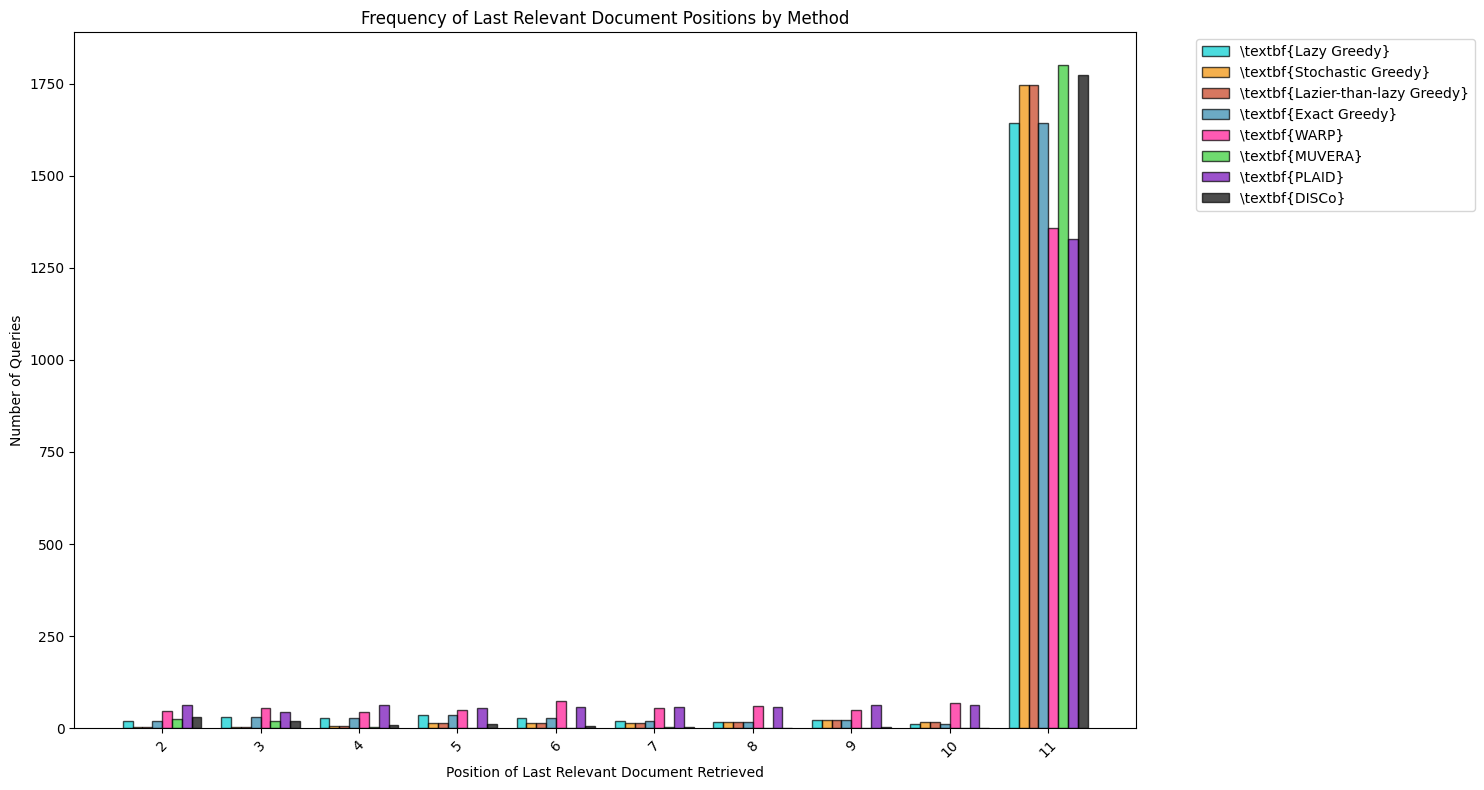

In [155]:
import pprint
# print("Scipy MAP")
# pprint.pprint(map_dict_1, indent=2)

# print("Other MAP")
# pprint.pprint(map_dict_2, indent=2)

# print("MRR")
# pprint.pprint(mrr_dict, indent=2)

# print("Mean Acc")
# pprint.pprint(acc_dict, indent=2)
methods_test = ['submodlib lazy', 'submodlib stochastic 0.5', 'submodlib ltl 0.5', 'exact greedy', 'WARP iid', 'MUVERA iid', 'ColBERT iid', 'ColBERT bypass - 1', 'gold']

import pandas as pd
from collections import Counter

print("Last rel Docs - Bar Plot")

# Get all unique positions across all methods
all_positions = set()
for method in methods_test:
    if method == 'gold':
        continue
    all_positions.update(last_rel_docs_dict[method])

all_positions = sorted(list(all_positions))

# Create data for grouped bar plot
data_for_plot = {}
for method in methods_test:
    if method == 'gold':
        continue
    
    # Count frequency of each position for this method
    position_counts = Counter(last_rel_docs_dict[method])
    method_counts = [position_counts.get(pos, 0) for pos in all_positions]
    data_for_plot[method] = method_counts

# Create DataFrame for easier plotting
df = pd.DataFrame(data_for_plot, index=all_positions)

# Create grouped bar plot
plt.figure(figsize=(15, 8))
width = 0.8 / len(df.columns)  # Width of each bar
x_positions = range(len(all_positions))

for i, method in enumerate(df.columns):
    if 'bypass' in method:
        color = 'black'
    elif 'ColBERT' in method and 'iid' in method:
        color = legend_color_map[method_label_map['ColBERT iid']]  # Use proper color mapping
    else:
        color = legend_color_map[method_label_map[method]]
    
    x_offset = [x + width * i for x in x_positions]
    plt.bar(x_offset, df[method], width, alpha=0.7, 
            label=method_label_map[method], color=color, edgecolor='black')

plt.xlabel('Position of Last Relevant Document Retrieved')
plt.ylabel('Number of Queries') 
plt.title('Frequency of Last Relevant Document Positions by Method')
plt.xticks([x + width * (len(df.columns) - 1) / 2 for x in x_positions], 
           all_positions, rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# print("Last rel Docs")
# for method in methods_test:
#     if method == 'gold':
#         continue
#     if 'bypass' in method:
#         color = 'black'
#     elif 'ColBERT' in method and 'iid' in method:
#         color = 'white'
#     else:
#         color = legend_color_map[method_label_map[method]]

#     # Bar plot of frequency of last relevant document positions
    
#     plt.bar()
#     plt.hist(last_rel_docs_dict[method], bins=10, alpha=0.6, label=method, color=color,
#              histtype='stepfilled', edgecolor='black')
# plt.xlabel('Position of Last Relevant Document Retrieved')
# plt.ylabel('Number of Queries')
# plt.title('Histogram of Last Relevant Document Positions by Method')
# plt.legend()
# plt.show()

In [156]:
import pandas as pd
from collections import Counter

def histogram_processing(methods, last_rel_docs_dict):
    # Get all unique positions across all methods
    all_positions = set()
    for method in methods_test:
        if method == 'gold':
            continue
        all_positions.update(last_rel_docs_dict[method])

    all_positions = sorted(list(all_positions))

    # Create data for grouped bar plot
    data_for_plot = {}
    for method in methods_test:
        if method == 'gold':
            continue

        # Count frequency of each position for this method
        position_counts = Counter(last_rel_docs_dict[method])
        method_counts = [position_counts.get(pos, 0) for pos in all_positions]
        data_for_plot[method] = method_counts

    # Create DataFrame for easier plotting
    df = pd.DataFrame(data_for_plot, index=all_positions)

    # keep only positions <= 5
    positions_to_show = [p for p in all_positions if p <= 5]

    # slice the DataFrame
    df_small = df.loc[positions_to_show]

    return df_small, positions_to_show

In [162]:
import pandas as pd
from collections import Counter


def plot_histogram(last_rel_docs_dict):
    methods_test = ['submodlib lazy', 'submodlib stochastic 0.5', 'submodlib ltl 0.5', 'exact greedy', 'WARP iid', 'MUVERA iid', 'ColBERT iid', 'ColBERT bypass - 1', 'gold']

    print("Last rel Docs - Bar Plot")

    plt.rcParams.update({
        'text.usetex': True,
        'text.latex.preamble': r'\usepackage{amsmath}',
        'font.family': 'serif',
        'figure.dpi': 300,
        # 'lines.markersize': 12
    })

    df_small, positions_to_show = histogram_processing(methods_test, last_rel_docs_dict)
    fig, ax = plt.subplots(figsize=(15, 8))
    # plt.figure(figsize=(15, 8))
    width = 0.8 / len(df_small.columns)
    x_positions = range(len(positions_to_show))

    for i, method in enumerate(df_small.columns):
        if 'bypass' in method:
            color = 'black'
        elif 'ColBERT' in method and 'iid' in method:
            color = plot_utils.legend_color_map[method_label_map['ColBERT iid']]  # Use proper color mapping
        else:
            color = plot_utils.legend_color_map[method_label_map[method]]
        x_offset = [x + width * i for x in x_positions]
        plt.bar(x_offset, df_small[method], width, alpha=0.7,
                label=plot_utils.method_label_map[method], color=color, edgecolor='black',
                align='center')

    ax.set_xlabel(r'\textbf{Rank of Last Relevant Item Retrieved}', fontsize=48)
    ax.set_ylabel(r'\textbf{Number of Queries}', fontsize=48)
    # plt.title('Frequency of Last Relevant Document Positions by Method')
    plt.xticks([x + width * (len(df_small.columns) - 1) / 2 for x in x_positions],
            positions_to_show) #, rotation=45)
    # plt.xticks([2, 3, 4, 5])

    # Explicitly set tick label sizes
    ax.tick_params(axis='x', labelsize=60)  # Smaller X-axis tick labels
    ax.tick_params(axis='y', labelsize=60)  # Smaller Y-axis tick labels

    # Get current x-tick values and format them with LaTeX bold
    xticks = ax.get_xticks()
    # xticklabels = [fr'$\mathbf{{{int(v)}}}$' for v in xticks]
    # xticklabels = [r'$\mathbf{0}$', r'$\mathbf{2}$', r'$\mathbf{3}$', r'$\mathbf{4}$', r'$\mathbf{5}$']
    # ax.set_xticklabels(xticklabels)

    # Get current y-tick values and format them with LaTeX bold
    yticks = ax.get_yticks()
    yticklabels = [fr'$\mathbf{{{int(v)}}}$' for v in yticks]
    ax.set_yticklabels(yticklabels)

    # plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f'./notebooks/plots/{dataset_name}_plot3_5_histogram.pdf', bbox_inches='tight', dpi=300)
    plt.show()


Last rel Docs - Bar Plot


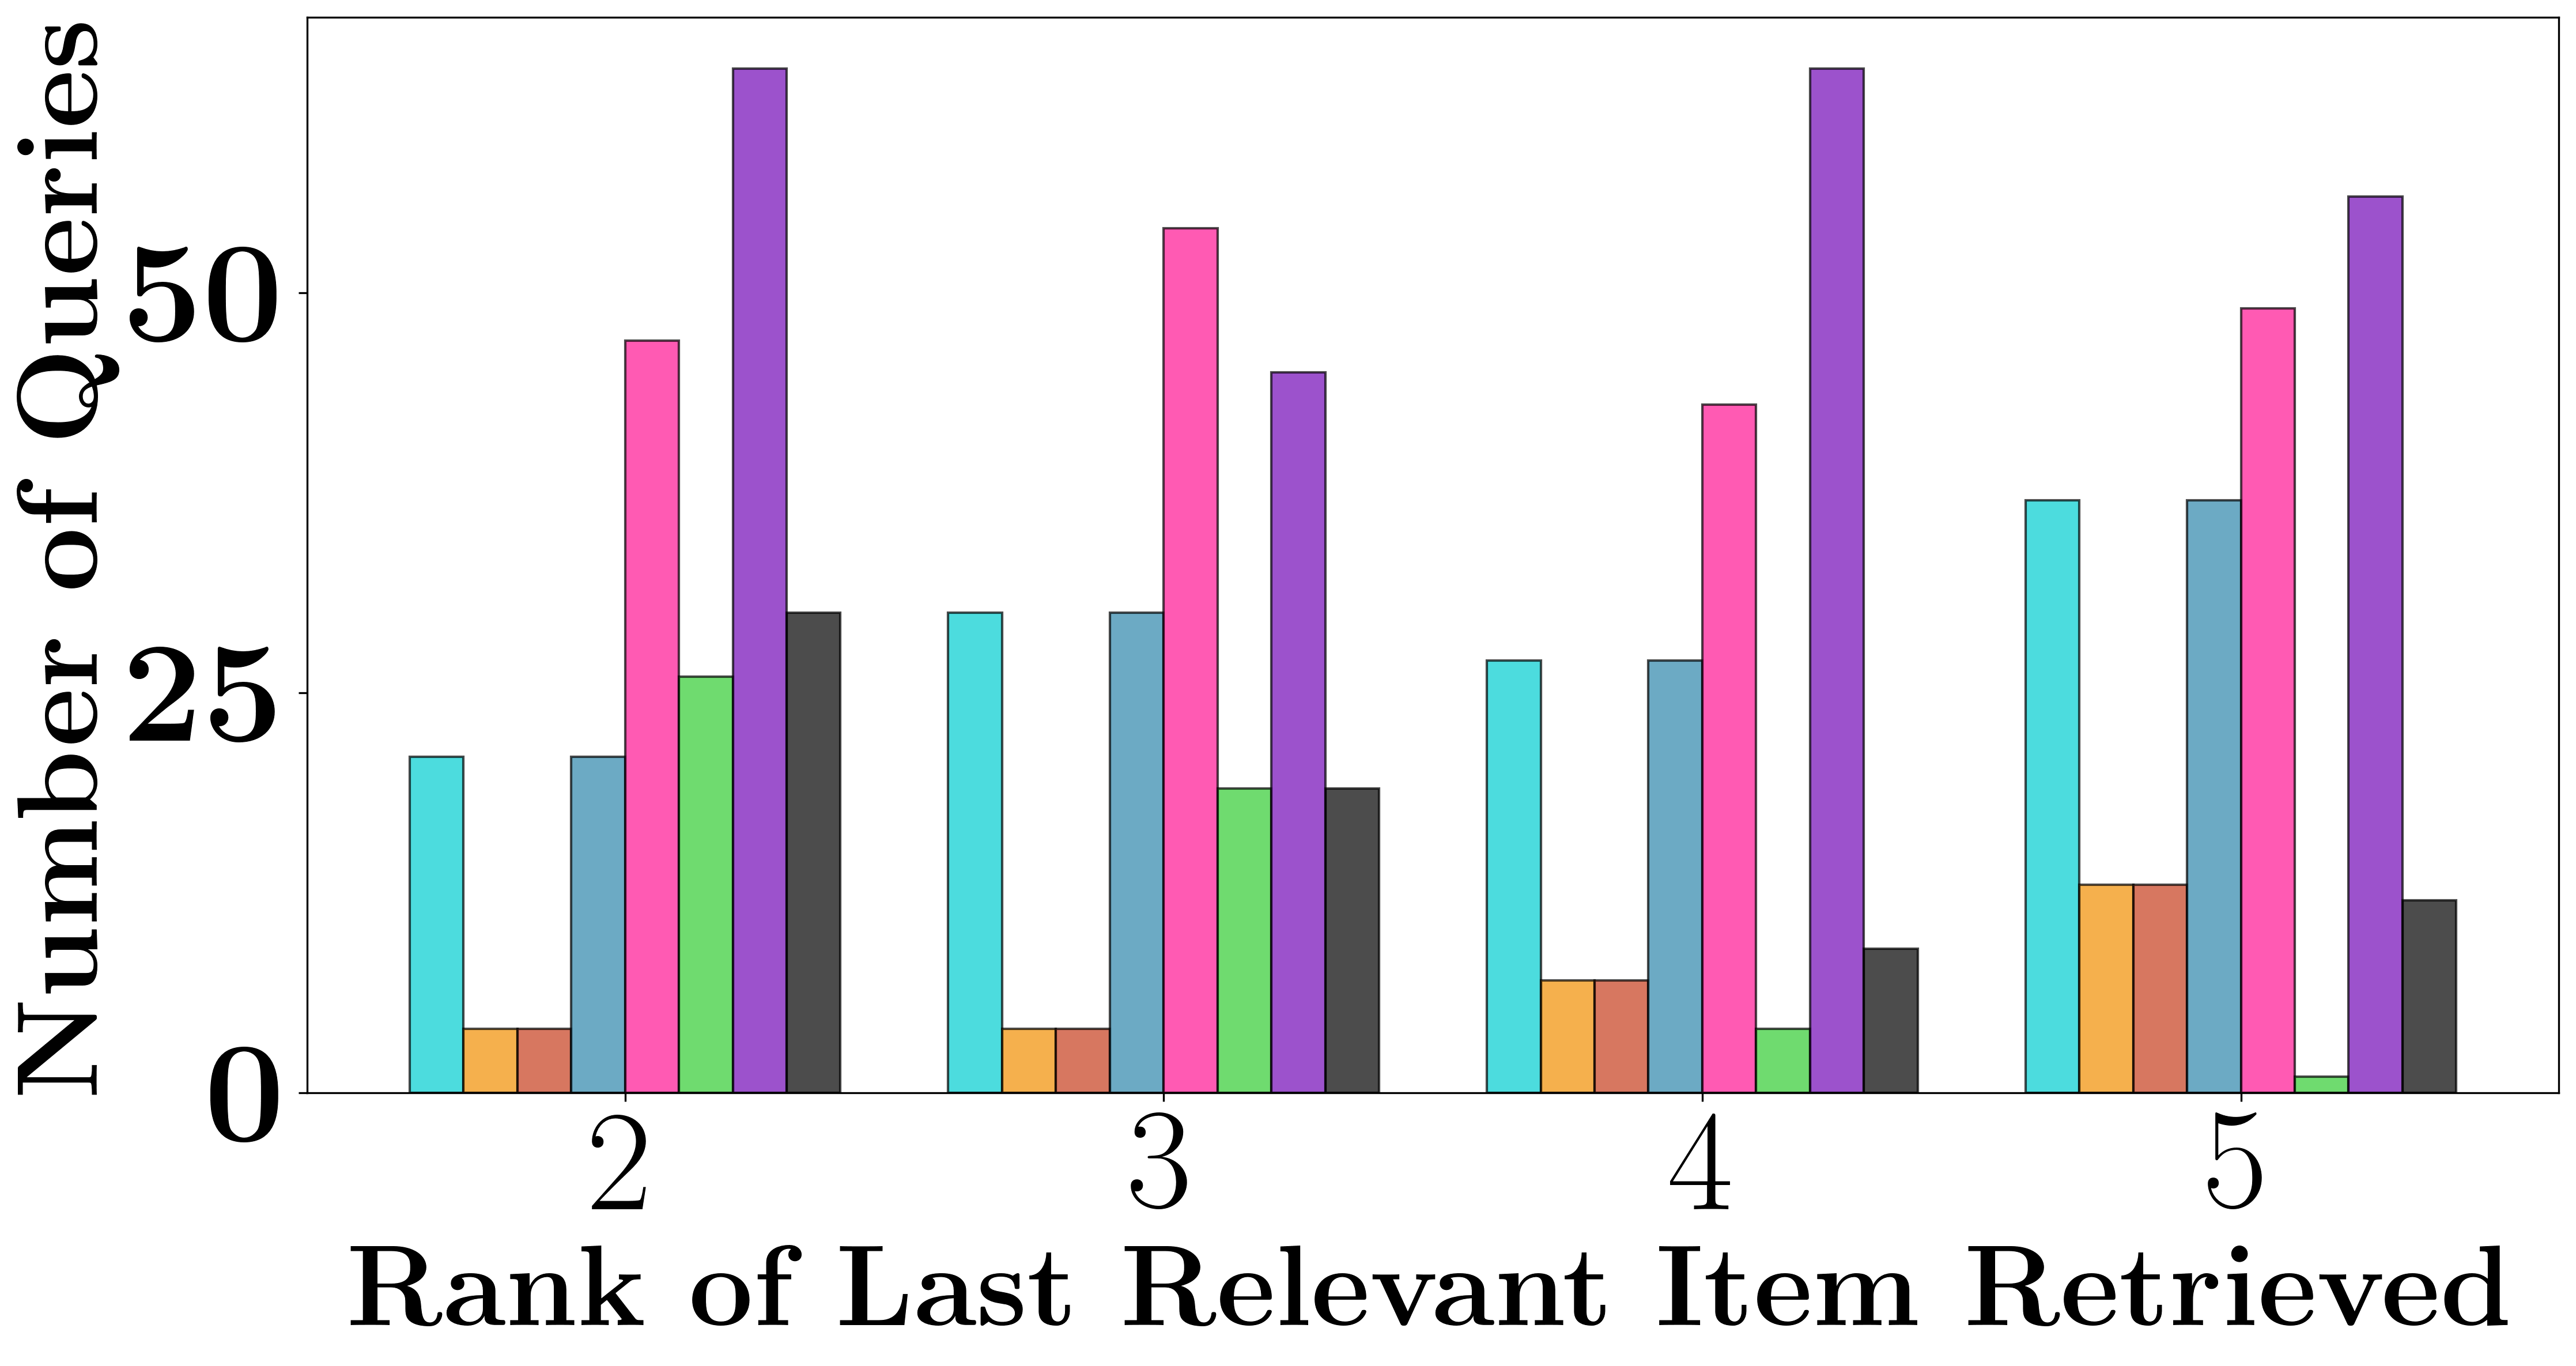

In [163]:
plot_histogram(last_rel_docs_dict)

In [329]:
import pandas as pd
from collections import Counter


def plot_histogram_legend(last_rel_docs_dict, filename, ncol=3, auto_crop=True):
    methods_test = ['ColBERT bypass - 1', 'submodlib ltl 0.5', 'exact greedy', 'MUVERA iid', 'submodlib lazy', 'WARP iid', 'submodlib stochastic 0.5', 'ColBERT iid']
    print("Last rel Docs - Bar Plot")

    plt.rcParams.update({
        'text.usetex': True,
        'text.latex.preamble': r'\usepackage{amsmath}',
        'font.family': 'serif',
        'figure.dpi': 300,
        'lines.markersize': 12
    })

    df_small, positions_to_show = histogram_processing(methods_test, last_rel_docs_dict)
    fig, ax = plt.subplots(figsize=(15, 8))
    # plt.figure(figsize=(15, 8))
    width = 0.8 / len(df_small.columns)
    x_positions = range(len(positions_to_show))

    for i, method in enumerate(df_small.columns):
        if 'bypass' in method:
            color = 'black'
        elif 'ColBERT' in method and 'iid' in method:
            color = plot_utils.legend_color_map[method_label_map['ColBERT iid']]  # Use proper color mapping
        else:
            color = plot_utils.legend_color_map[method_label_map[method]]
        x_offset = [x + width * i for x in x_positions]
        plt.bar([], [], width, alpha=0.7,
                label=plot_utils.method_label_map[method], color=color, edgecolor='black')

    # Create legend
    legend = ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.1),
        ncol=ncol,
        fontsize=25,
        frameon=False
    )

    # Save the figure
    output_path = f'./notebooks/plots/{filename}.pdf'
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0.1, dpi=300)
    plt.show()
    
    # Auto-crop the PDF if requested
    if auto_crop:
        # Try methods in order of preference
        cropped_path = crop_pdf_with_pdfcrop(output_path)
        if cropped_path is None:
            cropped_path = crop_pdf_with_fitz(output_path)
        if cropped_path is None:
            cropped_path = crop_pdf_with_pypdf(output_path)
        
        if cropped_path:
            # Replace original with cropped version
            os.rename(cropped_path, output_path)
            print(f"PDF automatically cropped: {output_path}")
        else:
            print("Auto-cropping failed, using matplotlib's bbox_inches='tight' only")


In [334]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def legend_only(methods_order, legend_color_map, method_label_map, filename, ncol=3):
    # Build labels & colors
    labels = [method_label_map[m] for m in methods_order]
    def color_for(m):
        if 'bypass' in m:
            return 'black'
        if 'ColBERT' in m and 'iid' in m:
            return plot_utils.legend_color_map[method_label_map['ColBERT iid']]
        return plot_utils.legend_color_map[method_label_map[m]]

    colors = [color_for(m) for m in methods_order]

    # Proxy handles for legend
    handles = [Patch(facecolor=c, edgecolor='black', label=lbl)
               for c, lbl in zip(colors, labels)]

    fig = plt.figure(figsize=(8, 2.2), dpi=300)
    # no axes at all
    leg = fig.legend(handles=handles,
                     loc="center", ncol=ncol, frameon=False, fontsize=30)
    fig.savefig(f'./notebooks/plots/{filename}.pdf',
                bbox_inches='tight', pad_inches=0.1)
    plt.show(fig)
    # plt.close(fig)


In [388]:
dms = ['ColBERT bypass - 1', 'submodlib ltl 0.5', 'exact greedy', 'MUVERA iid', 'submodlib lazy', 'WARP iid', 'submodlib stochastic 0.5', 'ColBERT iid']

legend_only(dms, legend_color_map=plot_utils.legend_color_map,
            method_label_map=plot_utils.method_label_map, filename='plot_3_5_legend', ncol=4)


<Figure size 2400x660 with 0 Axes>

In [173]:
for dataset in datasets:
    for method in methods:
        if method == "gold":
            scores = gc_mean
        else:
            scores = score_map[dataset][method].tolist()[:2]

        print(f"Method: {method}, dataset: {dataset}, scores: {scores}")

Method: submodlib lazy, dataset: hotpotqa, scores: [20.77775001525879, 24.150075912475586]
Method: submodlib stochastic 0.5, dataset: hotpotqa, scores: [17.124168395996094, 21.010772705078125]
Method: submodlib ltl 0.1, dataset: hotpotqa, scores: [17.91053009033203, 21.84095001220703]
Method: submodlib ltl 0.5, dataset: hotpotqa, scores: [16.761524200439453, 20.62693977355957]
Method: submodlib ltl 0.9, dataset: hotpotqa, scores: [15.248700141906738, 18.867860794067383]
Method: exact greedy, dataset: hotpotqa, scores: [20.77775001525879, 24.150075912475586]
Method: WARP iid, dataset: hotpotqa, scores: [20.61368751525879, 22.261213302612305]
Method: MUVERA iid, dataset: hotpotqa, scores: [18.806304931640625, 20.090028762817383]
Method: ColBERT iid, dataset: hotpotqa, scores: [20.762149810791016, 22.529996871948242]
Method: ColBERT bypass - 1, dataset: hotpotqa, scores: [20.763174057006836, 24.108600616455078]
Method: ColBERT angiogram - 1, dataset: hotpotqa, scores: [20.756580352783203,

### QRels avg and max set size

In [222]:
# Check msmarco specifically
class DummyConfig:
    loader_type = 'beir'
    dataset_name = 'msmarco'

dloader = get_dataloader(DummyConfig())
qrels_msmarco = dloader.get_qrels()
qrels_msmarco[0]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8841823/8841823 [00:36<00:00, 245223.17it/s]



KeyError: 0

In [224]:
qrels_msmarco['19335']

{'1017759': 0,
 '1082489': 0,
 '109063': 0,
 '1160863': 0,
 '1160871': 0,
 '1189088': 0,
 '1203500': 0,
 '1231806': 0,
 '1231807': 0,
 '1274615': 0,
 '1274620': 0,
 '1324075': 0,
 '1509459': 0,
 '1555317': 0,
 '1568085': 0,
 '161603': 0,
 '1705525': 0,
 '1720387': 0,
 '1720388': 0,
 '1720389': 1,
 '1720393': 0,
 '1720395': 1,
 '1722': 0,
 '1725697': 0,
 '1726': 0,
 '1729': 2,
 '1730': 0,
 '1796642': 0,
 '1796647': 0,
 '1825416': 0,
 '1825418': 0,
 '1837110': 0,
 '1871222': 0,
 '1908804': 0,
 '1956669': 0,
 '1958100': 0,
 '1958102': 0,
 '1958103': 0,
 '1959553': 0,
 '2004186': 0,
 '2046505': 1,
 '2071723': 0,
 '2130187': 0,
 '2186129': 0,
 '2304004': 0,
 '2304005': 0,
 '2324839': 0,
 '2325143': 0,
 '2382766': 0,
 '2394677': 0,
 '256744': 0,
 '256746': 0,
 '256750': 0,
 '2594897': 0,
 '2604487': 0,
 '2725017': 0,
 '2874503': 0,
 '2943092': 0,
 '2978577': 0,
 '3045565': 1,
 '3045567': 1,
 '3137952': 0,
 '3175481': 3,
 '3175483': 0,
 '3175484': 3,
 '3175485': 0,
 '3212083': 0,
 '3260688': 

In [231]:
# Check pooled specifically
class DummyConfig:
    loader_type = 'lotte'
    query_type = 'forum'
    dataset_name = 'pooled'

dloader = get_dataloader(DummyConfig())
qrels_pooled = dloader.get_qrels()

In [233]:
qrels_pooled['0']

['14298',
 '14300',
 '14311',
 '14314',
 '14333',
 '14341',
 '14346',
 '14349',
 '14350',
 '14356',
 '14360',
 '14367',
 '14383',
 '14400',
 '14505',
 '14534',
 '14549',
 '41500',
 '161058',
 '163178']

In [248]:
# Check msmarco specifically
class DummyConfig:
    loader_type = 'beir'
    dataset_name = 'fever'

dloader = get_dataloader(DummyConfig())
qrels_fever = dloader.get_qrels()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5416568/5416568 [00:27<00:00, 198021.60it/s]


In [250]:
qrels_fever['163803']

{'Ukrainian_Soviet_Socialist_Republic': 1, 'United_Nations': 1}

In [391]:
for dataset in ['pooled', 'science', 'technology']:
    class DummyConfig:
        loader_type = 'lotte'
        query_type = 'forum'
        dataset_name = dataset

    dloader = get_dataloader(DummyConfig())
    qrels = dloader.get_qrels()
    print(f"Dataset: {dataset}, Number of queries with at least one relevant doc: {len(qrels)}")
    print(f"Avg relevant docs per query: {np.mean([len(v) for v in qrels.values()])}")
    print(f"Maximum relevant docs for a single query: {max(len([val for val in v if int(val) >= 1]) for v in qrels.values())}")

for dataset in ['msmarco', 'hotpotqa']:
    class DummyConfig:
        loader_type = 'beir'
        dataset_name = dataset

    dloader = get_dataloader(DummyConfig())
    qrels = dloader.get_qrels()
    print(f"Dataset: {dataset}, Number of queries with at least one relevant doc: {len(qrels)}")
    print(f"Avg relevant docs per query: {np.mean([len([val for val in v.values() if val >= 1]) for v in qrels.values()])}")
    print(f"Maximum value of relevance label: {max([max([int(val) for val in v.values()]) for v in qrels.values()])}")
    print(f"Maximum relevant docs for a single query: {max(len([val for val in v.values() if val >= 1]) for v in qrels.values())}")

Dataset: pooled, Number of queries with at least one relevant doc: 10025
Avg relevant docs per query: 6.138254364089776
Maximum relevant docs for a single query: 292
Dataset: science, Number of queries with at least one relevant doc: 2017
Avg relevant docs per query: 7.692117005453644
Maximum relevant docs for a single query: 141
Dataset: technology, Number of queries with at least one relevant doc: 2004
Avg relevant docs per query: 7.929141716566866
Maximum relevant docs for a single query: 292


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8841823/8841823 [01:23<00:00, 105372.46it/s]


Dataset: msmarco, Number of queries with at least one relevant doc: 43
Avg relevant docs per query: 95.3953488372093
Maximum value of relevance label: 3
Maximum relevant docs for a single query: 341


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5233329/5233329 [00:50<00:00, 104419.51it/s]


Dataset: hotpotqa, Number of queries with at least one relevant doc: 7405
Avg relevant docs per query: 2.0
Maximum value of relevance label: 1
Maximum relevant docs for a single query: 2


In [ ]:
dataset = 'fever'
class DummyConfig:
    loader_type = 'beir'
    dataset_name = dataset

dloader = get_dataloader(DummyConfig())
qrels = dloader.get_qrels()
print(f"Dataset: {dataset}, Number of queries with at least one relevant doc: {len(qrels)}")
print(f"Avg relevant docs per query: {np.mean([len([val for val in v.values() if val >= 1]) for v in qrels.values()])}")
print(f"Maximum value of relevance label: {max([max([int(val) for val in v.values()]) for v in qrels.values()])}")
print(f"Maximum relevant docs for a single query: {max(len([val for val in v.values() if val >= 1]) for v in qrels.values())}")


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5416568/5416568 [00:26<00:00, 203427.68it/s]


Dataset: fever, Number of queries with at least one relevant doc: 6666
Avg relevant docs per query: 1.1906690669066906
Maximum value of relevance label: 1
Maximum relevant docs for a single query: 15


In [253]:
print(f"Number of queries with exactly one relevant doc: {len([1 for v in qrels.values() if len([val for val in v.values() if val >= 1]) == 1])}")

Number of queries with exactly one relevant doc: 5819


In [254]:
print(f"Number of queries with two relevant doc: {len([1 for v in qrels.values() if len([val for val in v.values() if val >= 1]) == 2])}")

Number of queries with two relevant doc: 654


In [390]:
print(f"Number of queries with atleast two relevant doc: {len([1 for v in qrels.values() if len([val for val in v.values() if val >= 1]) >= 2])}")

Number of queries with atleast two relevant doc: 7405


In [255]:
print(f"Number of queries with three relevant doc: {len([1 for v in qrels.values() if len([val for val in v.values() if val >= 1]) == 3])}")

Number of queries with three relevant doc: 110


In [389]:
dataset = 'hotpotqa'
class DummyConfig:
    loader_type = 'beir'
    dataset_name = dataset

dloader = get_dataloader(DummyConfig())
qrels = dloader.get_qrels()
print(f"Dataset: {dataset}, Number of queries with at least one relevant doc: {len(qrels)}")
print(f"Avg relevant docs per query: {np.mean([len([val for val in v.values() if val >= 1]) for v in qrels.values()])}")
print(f"Maximum value of relevance label: {max([max([int(val) for val in v.values()]) for v in qrels.values()])}")
print(f"Maximum relevant docs for a single query: {max(len([val for val in v.values() if val >= 1]) for v in qrels.values())}")


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5233329/5233329 [00:42<00:00, 121841.54it/s]


Dataset: hotpotqa, Number of queries with at least one relevant doc: 7405
Avg relevant docs per query: 2.0
Maximum value of relevance label: 1
Maximum relevant docs for a single query: 2
